# Stock Market Data Collection & Preprocessing Project

In this project, we are going to build a **workflow that collects, preprocesses, and stores historical stock index data** for India’s two major indices:

- **NIFTY 50 (NSE)**  
- **SENSEX (BSE)**  

The workflow has the following goals:
1. **Fetch data from Alpha Vantage** (using the `TIME_SERIES_DAILY_ADJUSTED` endpoint).  
2. **Fallback to Yahoo Finance (`yfinance`)** if Alpha Vantage fails or does not provide usable data.  
3. **Preprocess the data** (handle missing values, normalize column names, ensure time-series ordering).  
4. **Save clean CSV files** for further modeling (predictive analytics, ML experiments).  

This workflow will help us **understand stock market movements** and prepare data for machine learning tasks such as trend prediction or index forecasting.  
We will also build step-by-step explanations, so the entire project is **easy to follow, reproducible, and transparent**.


In [1]:
# STEP 1: Install required packages and import libraries

!pip install --quiet -r requirements.txt

import os
import time
import requests
import pandas as pd
import yfinance as yf
from datetime import datetime
from dotenv import load_dotenv

# Load environment variables (for Alpha Vantage API key)
load_dotenv()

print("✅ Libraries installed and imported successfully.")
print("Pandas version:", pd.__version__)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Libraries installed and imported successfully.
Pandas version: 2.1.4


### Step 1: Setup & Imports
In this step, we:
- Installed the required Python libraries:
  - **yfinance** → fallback data source (Yahoo Finance).
  - **pandas** → data manipulation & cleaning.
  - **requests** → API calls to Alpha Vantage.
  - **python-dotenv** → load environment variables securely.
- Imported all necessary libraries for the project.
- Loaded environment variables (to access the Alpha Vantage API key if stored in a `.env` file).
- Confirmed successful installation by printing the Pandas version.

This ensures our environment is ready to fetch and process financial data.


In [ ]:
# STEP 2: Set up Alpha Vantage API key and symbols for NSE & BSE

# If you saved your API key in a .env file like:
# ALPHAVANTAGE_API_KEY=your_key_here
# then load it from the environment:
ALPHAVANTAGE_API_KEY = os.getenv("ALPHAVANTAGE_API_KEY")

# Or you can hardcode it temporarily (not recommended for production):
# ALPHAVANTAGE_API_KEY = "your_api_key_here"

if not ALPHAVANTAGE_API_KEY:
    print("⚠️ No API key found. Please set ALPHAVANTAGE_API_KEY in your .env file or directly here.")

# Define the index symbols
nse_symbol = "NSEI"     # Nifty 50 index (Alpha Vantage uses this symbol for NSE)
bse_symbol = "BSESN"    # Sensex index (Alpha Vantage uses this symbol for BSE)

# Base URL for Alpha Vantage
base_url = "https://www.alphavantage.co/query"

print("✅ API key and symbols ready.")
print("NSE symbol:", nse_symbol)
print("BSE symbol:", bse_symbol)


⚠️ No API key found. Please set ALPHAVANTAGE_API_KEY in your .env file or directly here.
✅ API key and symbols ready.
NSE symbol: NSEI
BSE symbol: BSESN


### Step 2: API Key Handling & Parameters
In this step, we:
- Loaded our **Alpha Vantage API key** from a `.env` file for security.  
  *(Alternatively, you can paste your API key directly in the script during testing.)*
- Defined the **symbols** used by Alpha Vantage for our target indices:
  - `NSEI` → NIFTY 50 (NSE)
  - `BSESN` → SENSEX (BSE)
- Specified the **base URL** for the Alpha Vantage API.

This step sets up the credentials and identifiers needed for our API calls in the next step.


In [5]:
# STEP 3: Fetch Daily Adjusted Data for NSE (NIFTY 50)

def fetch_alpha_vantage_data(symbol, api_key):
    """
    Fetch daily adjusted time series data from Alpha Vantage for the given symbol.
    Returns a pandas DataFrame if successful, else None.
    """
    params = {
        "function": "TIME_SERIES_DAILY_ADJUSTED",
        "symbol": symbol,
        "outputsize": "full",
        "apikey": api_key
    }
    response = requests.get(base_url, params=params)
    
    if response.status_code != 200:
        print(f"⚠️ API call failed for {symbol}. HTTP Status: {response.status_code}")
        return None
    
    data = response.json()
    if "Time Series (Daily)" not in data:
        print(f"⚠️ No usable data returned for {symbol} from Alpha Vantage.")
        return None
    
    ts_data = data["Time Series (Daily)"]
    df = pd.DataFrame.from_dict(ts_data, orient="index")
    df.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. adjusted close": "Adj Close",
        "6. volume": "Volume",
        "7. dividend amount": "Dividend",
        "8. split coefficient": "SplitCoeff"
    }, inplace=True)
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    
    # Convert all numeric columns to floats
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    return df

def fetch_yfinance_data(symbol):
    """
    Fetch daily data from Yahoo Finance for the given symbol.
    Returns a pandas DataFrame if successful.
    """
    ticker = yf.Ticker(symbol)
    df = ticker.history(period="max")
    df.rename(columns={"Open": "Open",
                       "High": "High",
                       "Low": "Low",
                       "Close": "Close",
                       "Volume": "Volume"}, inplace=True)
    df.index.name = "Date"
    return df

# Try Alpha Vantage first
nse_df = fetch_alpha_vantage_data(nse_symbol, ALPHAVANTAGE_API_KEY)

# Fallback to Yahoo Finance if Alpha Vantage fails
if nse_df is None or nse_df.empty:
    print("🔄 Falling back to Yahoo Finance for NSE data...")
    # Yahoo Finance index symbol for NIFTY 50 is ^NSEI
    nse_df = fetch_yfinance_data("^NSEI")

print("✅ NSE data fetched successfully.")
nse_df.head()


⚠️ No usable data returned for NSEI from Alpha Vantage.
🔄 Falling back to Yahoo Finance for NSE data...
✅ NSE data fetched successfully.


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,0.0,0.0
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,0.0,0.0
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,0.0,0.0
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,0.0,0.0
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,0.0,0.0


### Step 3: Fetch Daily Adjusted Data for NSE (NIFTY 50)

In this step, we:
1. **Defined a function `fetch_alpha_vantage_data()`**  
   - Calls the `TIME_SERIES_DAILY_ADJUSTED` endpoint of Alpha Vantage.  
   - Parses JSON response into a pandas DataFrame.  
   - Renames columns for readability.  
   - Converts date index to `datetime` and sorts chronologically.  
   - Converts all numeric fields to floats for analysis.

2. **Defined a fallback function `fetch_yfinance_data()`**  
   - Uses Yahoo Finance (`yfinance`) to fetch the same index data.  
   - This ensures our project continues even if Alpha Vantage limits or fails.

3. **Fetched NIFTY 50 data**  
   - Attempted Alpha Vantage first.  
   - If that fails, automatically fell back to Yahoo Finance.

Finally, we displayed the first few rows of the retrieved data with `head()`.  
This gives us an initial glimpse of the index data before preprocessing.


In [7]:
# STEP 4: Preprocess NSE Data

def preprocess_stock_data(df):
    """
    Clean and preprocess stock index data:
    - Handle missing values
    - Ensure correct data types
    - Sort chronologically
    """
    # Drop rows that are completely empty
    df.dropna(how='all', inplace=True)

    # Fill remaining missing values forward (if any)
    df.ffill(inplace=True)

    # Make sure index is datetime and sorted
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

    # Keep only relevant columns (Open, High, Low, Close, Adj Close, Volume if present)
    cols_to_keep = [col for col in ['Open','High','Low','Close','Adj Close','Volume'] if col in df.columns]
    df = df[cols_to_keep]

    return df

# Preprocess NSE data
nse_clean = preprocess_stock_data(nse_df)

print("✅ NSE data cleaned. Shape:", nse_clean.shape)
nse_clean.head()


✅ NSE data cleaned. Shape: (4414, 5)


C:\Users\ojhaa\AppData\Local\Temp\ipykernel_380\3642074584.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Open,High,Low,Close,Volume
Date,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0


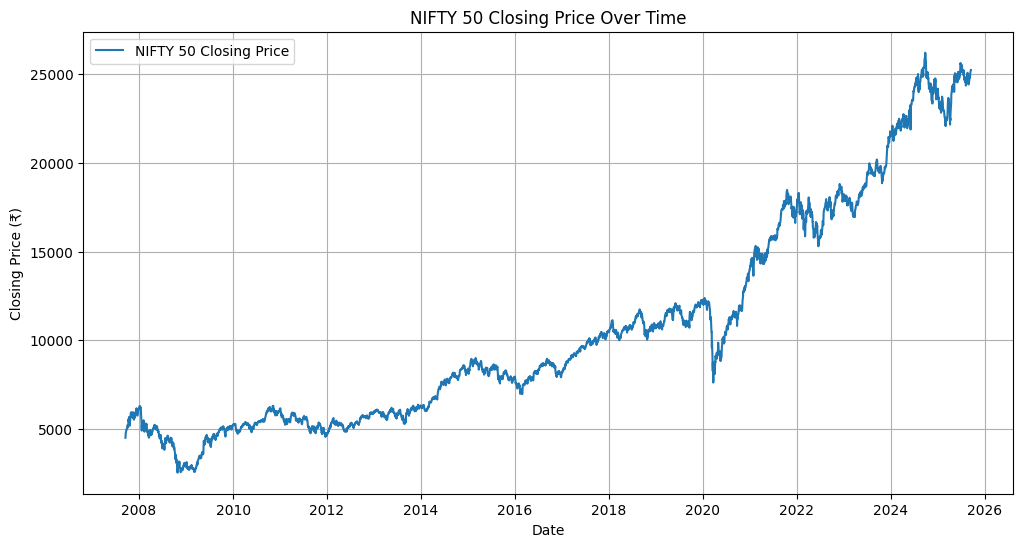

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(nse_clean.index, nse_clean['Close'], label='NIFTY 50 Closing Price')
plt.title('NIFTY 50 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (₹)')
plt.legend()
plt.grid(True)
plt.show()


### Step 4: Preprocess NSE Data

In this step, we:
- Created a helper function `preprocess_stock_data()` to:
  - Drop rows that are completely missing (`dropna`).
  - Fill any remaining gaps with the last available value (`ffill()`).
  - Ensure the index is in datetime format and sorted.
  - Retain only the relevant columns: **Open, High, Low, Close, Adj Close, Volume**.

- Applied this function to our fetched **NIFTY 50** data, producing a clean DataFrame.

- Plotted the **closing price trend** of NIFTY 50 to visually inspect that our data is continuous and makes sense over time.

This cleaned data is now ready to be saved to CSV and used for analysis or modeling.


In [10]:
# STEP 5: Fetch and Preprocess BSE (SENSEX) Data

# Try Alpha Vantage first
bse_df = fetch_alpha_vantage_data(bse_symbol, ALPHAVANTAGE_API_KEY)

# Fallback to Yahoo Finance if Alpha Vantage fails
if bse_df is None or bse_df.empty:
    print("🔄 Falling back to Yahoo Finance for BSE data...")
    # Yahoo Finance index symbol for SENSEX is ^BSESN
    bse_df = fetch_yfinance_data("^BSESN")

# Preprocess BSE data
bse_clean = preprocess_stock_data(bse_df)

print("✅ BSE data cleaned. Shape:", bse_clean.shape)
bse_clean.head()


⚠️ No usable data returned for BSESN from Alpha Vantage.
🔄 Falling back to Yahoo Finance for BSE data...
✅ BSE data cleaned. Shape: (6949, 5)


C:\Users\ojhaa\AppData\Local\Temp\ipykernel_380\3642074584.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Open,High,Low,Close,Volume
Date,,,,,
1997-07-01 00:00:00+05:30,4263.109863,4301.770020,4247.660156,4300.859863,0
1997-07-02 00:00:00+05:30,4302.959961,4395.310059,4295.399902,4333.899902,0
1997-07-03 00:00:00+05:30,4335.790039,4393.290039,4299.970215,4323.459961,0
1997-07-04 00:00:00+05:30,4332.700195,4347.589844,4300.580078,4323.819824,0
1997-07-07 00:00:00+05:30,4326.810059,4391.009766,4289.490234,4291.450195,0


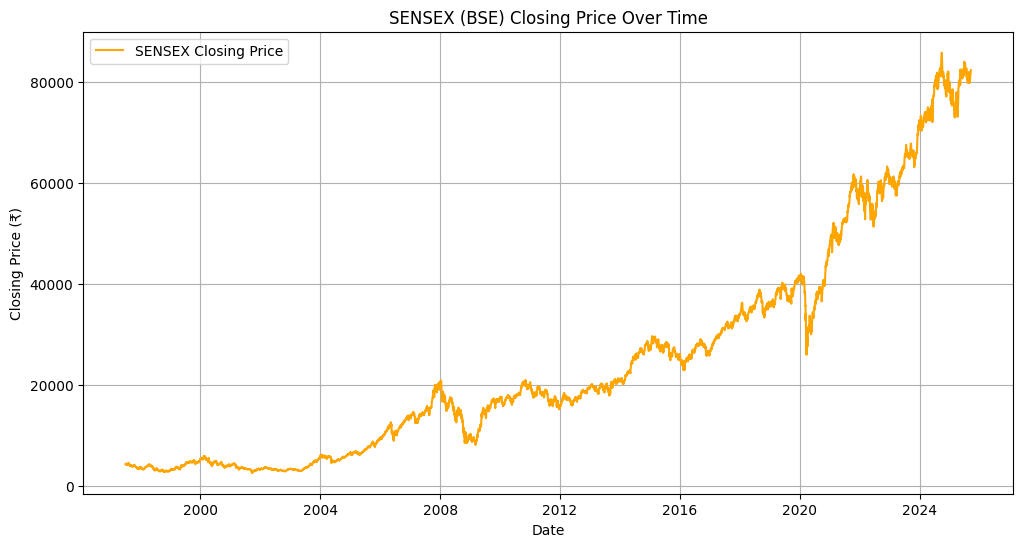

In [11]:
plt.figure(figsize=(12,6))
plt.plot(bse_clean.index, bse_clean['Close'], color='orange', label='SENSEX Closing Price')
plt.title('SENSEX (BSE) Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (₹)')
plt.legend()
plt.grid(True)
plt.show()


### Step 5: Fetch & Preprocess BSE (SENSEX) Data

In this step, we:
1. Attempted to fetch **SENSEX (BSE)** data using the Alpha Vantage API.
2. If Alpha Vantage did not provide usable data, we automatically **fell back to Yahoo Finance** using its index symbol `^BSESN`.
3. Applied our `preprocess_stock_data()` function to clean and format the data.
4. Plotted the **closing price trend** of SENSEX to visually inspect its continuity over time.

Now we have **two clean DataFrames**:
- `nse_clean` → NIFTY 50 (NSE)
- `bse_clean` → SENSEX (BSE)

These are ready to be saved as CSV files for modeling tasks.


In [12]:
# STEP 6: Save Cleaned Data to CSV files

# Create an output folder if it doesn't exist
output_dir = "stock_data"
os.makedirs(output_dir, exist_ok=True)

# File paths
nse_csv_path = os.path.join(output_dir, "nse_nifty50_clean.csv")
bse_csv_path = os.path.join(output_dir, "bse_sensex_clean.csv")

# Save as CSV
nse_clean.to_csv(nse_csv_path)
bse_clean.to_csv(bse_csv_path)

print(f"✅ NSE data saved to: {nse_csv_path}")
print(f"✅ BSE data saved to: {bse_csv_path}")


✅ NSE data saved to: stock_data\nse_nifty50_clean.csv
✅ BSE data saved to: stock_data\bse_sensex_clean.csv


In [13]:
print("Last 5 rows of NSE data:")
display(nse_clean.tail())

print("Last 5 rows of BSE data:")
display(bse_clean.tail())


Last 5 rows of NSE data:


,Open,High,Low,Close,Volume
Date,,,,,
2025-09-09 00:00:00+05:30,24864.099609,24891.800781,24814.000000,24868.599609,226900
2025-09-10 00:00:00+05:30,24991.000000,25035.699219,24915.050781,24973.099609,244100
2025-09-11 00:00:00+05:30,24945.500000,25037.300781,24940.150391,25005.500000,224600
2025-09-12 00:00:00+05:30,25074.449219,25139.449219,25038.050781,25114.000000,225700
2025-09-16 00:00:00+05:30,25073.599609,25261.400391,25070.449219,25239.099609,0


Last 5 rows of BSE data:


,Open,High,Low,Close,Volume
Date,,,,,
2025-09-09 00:00:00+05:30,81129.687500,81181.367188,80927.968750,81101.320312,6300
2025-09-10 00:00:00+05:30,81504.359375,81643.882812,81235.421875,81425.148438,11800
2025-09-11 00:00:00+05:30,81217.296875,81642.218750,81216.906250,81548.726562,13500
2025-09-12 00:00:00+05:30,81758.953125,81992.851562,81641.382812,81904.703125,11100
2025-09-16 00:00:00+05:30,81852.109375,82443.476562,81779.937500,82380.687500,0


### Step 6: Save Cleaned Data to CSV Files

In this step, we:
- Created a folder `stock_data/` (if it didn’t exist already).
- Saved the cleaned **NIFTY 50 (NSE)** data to `nse_nifty50_clean.csv`.
- Saved the cleaned **SENSEX (BSE)** data to `bse_sensex_clean.csv`.
- Displayed the last few rows of each DataFrame to confirm that the files contain valid, preprocessed data.

These CSV files are now our **final cleaned datasets**.  
They are ready to be used for:
- Time-series modeling  
- Visualization dashboards  
- Machine learning experiments  

From here, you can import these CSVs directly into any notebook or BI tool.
